# 3. CatBoost

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_train.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_test.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_train.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_test.parquet"
)["Label"]

label_mapping = pd.read_csv(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/label_mapping.csv"
)

class_names = label_mapping["class_name"].values
classes = np.arange(len(class_names))

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

(1785379, 77)
(446345, 77)
(1785379,)
(446345,)


In [2]:
from catboost import CatBoostClassifier

cat_before = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

cat_before.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)

In [3]:
import joblib

joblib.dump(
    cat_before,
    "/kaggle/working/catboost_model.pkl"
)

print("CatBoost model saved.")

CatBoost model saved.


In [4]:
y_pred_cat_before = (
    cat_before.predict(X_test)
    .flatten()
    .astype(int)
)

y_prob_cat_before = cat_before.predict_proba(X_test)

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred_cat_before
)

precision_weighted = precision_score(
    y_test,
    y_pred_cat_before,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test,
    y_pred_cat_before,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test,
    y_pred_cat_before,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test,
    y_pred_cat_before,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test,
    y_pred_cat_before,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test,
    y_pred_cat_before,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_test,
    y_pred_cat_before
)

auc = roc_auc_score(
    y_test_bin,
    y_prob_cat_before,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")
print(f"Macro Precision    : {precision_macro:.4f}")
print(f"Macro Recall       : {recall_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"AUC                : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cat_before,
        target_names=class_names,
        zero_division=0
    )
)

Accuracy           : 0.9980
Weighted Precision : 0.9981
Weighted Recall    : 0.9980
Weighted F1        : 0.9978
Macro Precision    : 0.9063
Macro Recall       : 0.7173
Macro F1           : 0.7462
MCC                : 0.9926
AUC                : 0.9999

Classification Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    379047
                       Bot       1.00      0.51      0.68       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.98      0.99      2057
                  DoS Hulk       1.00      0.99      1.00     34569
          DoS Slowhttptest       0.95      0.98      0.96      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      0.98      0.99      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      

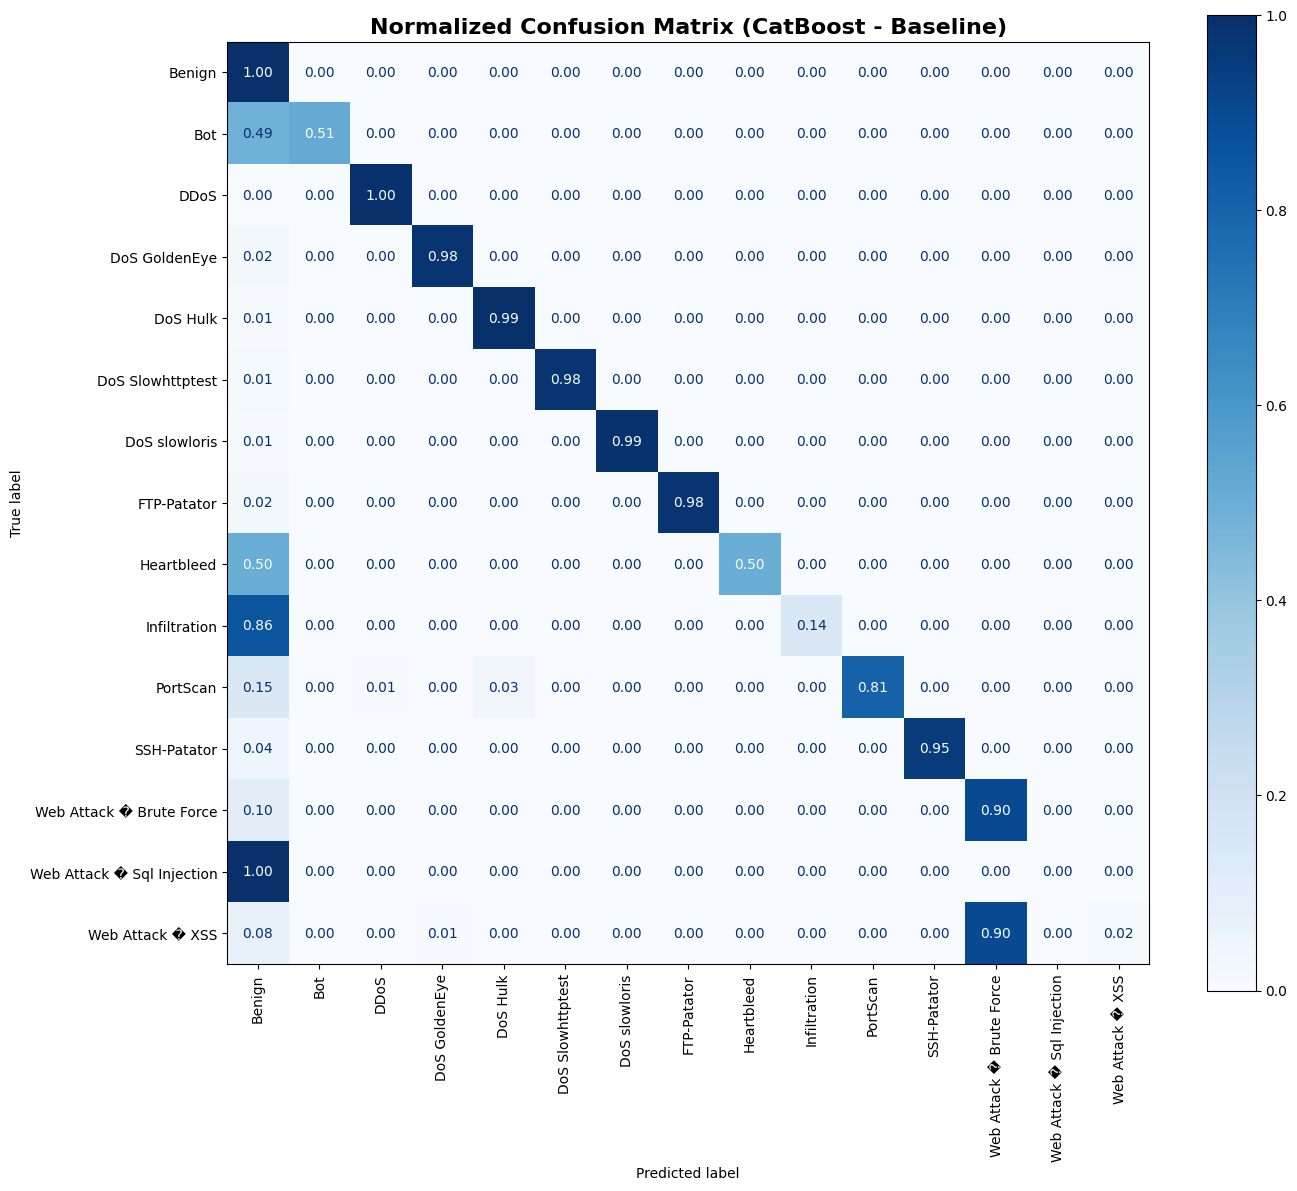

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cat_before,
    labels=classes,
    display_labels=class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Normalized Confusion Matrix (CatBoost - Baseline)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/catboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
catboost_results = pd.DataFrame({
    "Model": ["CatBoost"],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision_weighted],
    "Weighted Recall": [recall_weighted],
    "Weighted F1": [f1_weighted],
    "Macro Precision": [precision_macro],
    "Macro Recall": [recall_macro],
    "Macro F1": [f1_macro],
    "MCC": [mcc],
    "AUC": [auc]
})

catboost_results.to_csv(
    "/kaggle/working/catboost_results.csv",
    index=False
)

print(catboost_results)

      Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  CatBoost  0.998022            0.998079         0.998022     0.997836   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.906266      0.717303  0.746204  0.992644  0.999929  


In [8]:
catboost_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_cat_before
})

catboost_predictions.to_csv(
    "/kaggle/working/catboost_predictions.csv",
    index=False
)

print("CatBoost predictions saved.")

CatBoost predictions saved.
